# Bloque IV — Clustering, silhouette y PCA

**Duración estimada:** 3 horas  
**Dataset:** `../data/segmentacion_clientes_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a aplicar clustering para segmentación, seleccionar un número razonable de grupos, evaluar la calidad mediante silhouette y visualizar los resultados con PCA.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Aprendizaje no supervisado |
| 0:25–0:55 | Escalado y preparación |
| 0:55–1:25 | K-Means y método del codo |
| 1:25–1:35 | Pausa |
| 1:35–2:05 | Silhouette score |
| 2:05–2:35 | PCA para visualización |
| 2:35–3:00 | Perfilado de clusters |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. Carga del dataset

En clustering no tenemos variable objetivo. Queremos descubrir grupos de clientes con comportamientos similares.

In [3]:
df = pd.read_csv("../data/segmentacion_clientes_mayo_2026.csv")
df.head()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones,cliente_id
0,"32,713.931",2.799,57.118,15.884,74.291,0,S2000
1,"79,117.581",26.885,152.289,67.328,7.116,2,S2001
2,"67,501.684",20.624,185.243,92.128,4.397,4,S2002
3,"42,542.107",6.134,53.108,31.597,22.767,2,S2003
4,"26,341.425",4.283,34.558,6.006,76.764,0,S2004


## 2. Selección de variables

Elegimos variables numéricas que describen comportamiento, valor y relación comercial.

In [4]:
features = [
    "ingresos",
    "compras_12m",
    "ticket_medio",
    "visitas_web",
    "dias_desde_ultima_compra",
    "reclamaciones"
]

X = df[features]
X.describe()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
count,450.000,450.000,450.000,450.000,450.000,450.000
mean,"42,289.169",10.307,97.951,42.700,41.753,0.798
std,"18,578.010",7.371,62.024,30.532,34.033,0.904
min,"11,050.131",0.000,5.191,1.409,0.000,0.000
25%,"26,022.301",3.330,45.193,14.163,12.876,0.000
50%,"40,131.094",9.638,84.340,40.017,26.511,1.000
75%,"56,026.542",15.929,148.942,63.006,73.576,1.000
max,"89,194.662",31.685,254.151,127.680,137.408,5.000


## 3. Escalado

K-Means se basa en distancias, por lo que las variables deben estar en escalas comparables.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).describe()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
count,450.000,450.000,450.000,450.000,450.000,450.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.683,-1.400,-1.497,-1.354,-1.228,-0.884
25%,-0.877,-0.948,-0.852,-0.936,-0.849,-0.884
50%,-0.116,-0.091,-0.220,-0.088,-0.448,0.224
75%,0.740,0.764,0.823,0.666,0.936,0.224
max,2.528,2.904,2.521,2.786,2.814,4.656


## 4. K-Means inicial

Probamos inicialmente con 3 clusters para entender el flujo completo.

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters
df["cluster"].value_counts()

cluster
1    177
2    147
0    126
Name: count, dtype: int64

## 5. Método del codo

La inercia mide la compactación interna de los clusters. Al aumentar k, la inercia baja, pero buscamos un punto donde la mejora marginal se reduzca.

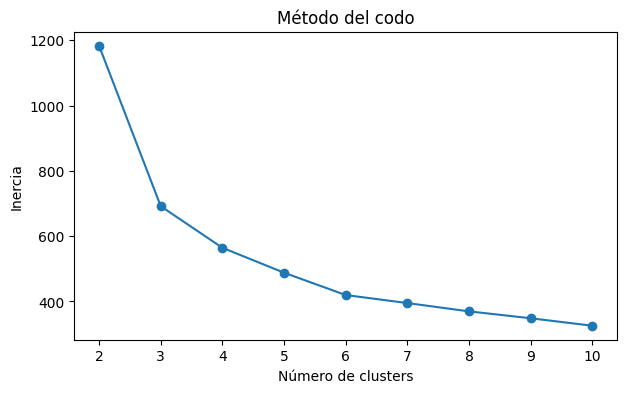

In [7]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

## 6. Silhouette score

Silhouette combina cohesión y separación. Valores cercanos a 1 indican clusters más claros.

In [8]:
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouettes.append(score)

sil_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette": silhouettes
})

sil_df

,k,silhouette
0,2,0.482
1,3,0.476
2,4,0.459
3,5,0.412
4,6,0.353
5,7,0.341
6,8,0.330
7,9,0.297
8,10,0.287


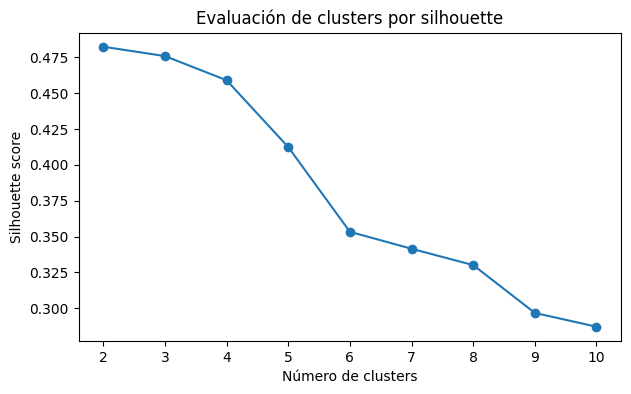

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Evaluación de clusters por silhouette")
plt.show()

## 7. Modelo final

Seleccionamos el número de clusters. En un proyecto real, la decisión combina métrica, interpretabilidad y utilidad de negocio.

In [10]:
k_final = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("k seleccionado por silhouette:", k_final)

modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = modelo_final.fit_predict(X_scaled)

df["cluster"].value_counts()

k seleccionado por silhouette: 2


cluster
0    273
1    177
Name: count, dtype: int64

## 8. PCA para visualización

PCA reduce la dimensionalidad a dos componentes para representar los grupos en un plano.

In [11]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df["PC1"] = componentes[:, 0]
df["PC2"] = componentes[:, 1]

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada: [0.74906859 0.13611323]
Varianza explicada acumulada: 0.885181818155716


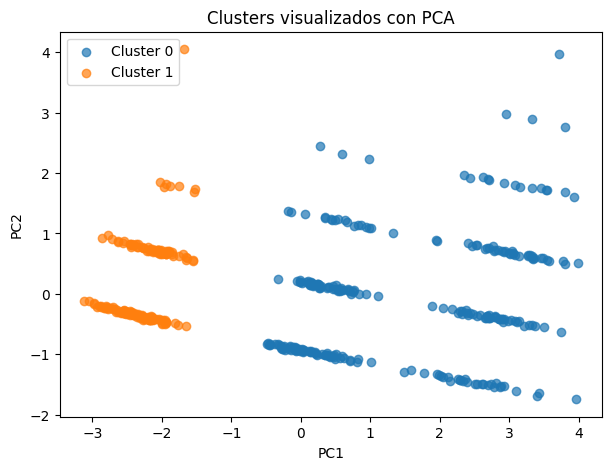

In [12]:
plt.figure(figsize=(7, 5))
for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters visualizados con PCA")
plt.legend()
plt.show()

## 9. Perfilado de clusters

El verdadero valor del clustering está en interpretar los grupos y traducirlos en acciones.

In [13]:
perfil_clusters = (
    df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

perfil_clusters

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
cluster,,,,,,
0,"54,003.760",15.030,135.300,62.250,16.700,1.010
1,"24,220.900",3.020,40.340,12.550,80.390,0.460


In [14]:
for cluster_id, row in perfil_clusters.iterrows():
    print(f"Cluster {cluster_id}")
    print(row.sort_values(ascending=False))
    print("-" * 50)

Cluster 0
ingresos                   54,003.760
ticket_medio                  135.300
visitas_web                    62.250
dias_desde_ultima_compra       16.700
compras_12m                    15.030
reclamaciones                   1.010
Name: 0, dtype: float64
--------------------------------------------------
Cluster 1
ingresos                   24,220.900
dias_desde_ultima_compra       80.390
ticket_medio                   40.340
visitas_web                    12.550
compras_12m                     3.020
reclamaciones                   0.460
Name: 1, dtype: float64
--------------------------------------------------


## 10. Propuesta de acciones

Ejemplo de lectura:

- Clientes con alto ticket y alta frecuencia: fidelización premium.
- Clientes con muchas visitas y pocas compras: campañas de conversión.
- Clientes con muchos días desde última compra: reactivación.
- Clientes con reclamaciones elevadas: mejora de experiencia.

## 11. Ejercicio integrador

1. Prueba K-Means con `k=2`, `k=3`, `k=4` y `k=5`.
2. Compara silhouette.
3. Visualiza cada solución con PCA.
4. Perfila los clusters de la mejor solución.
5. Asigna un nombre de negocio a cada cluster.
6. Propón una acción comercial para cada segmento.

### Entregable

Notebook con tabla de perfiles y conclusión por cluster.

1. COMPARACIÓN: k=2, 3, 4, 5
k=2: silhouette=0.4823
k=3: silhouette=0.4758
k=4: silhouette=0.4589
k=5: silhouette=0.4124

-> Mejor k por silhouette: 2.0

2. VISUALIZACIÓN CON PCA PARA CADA K


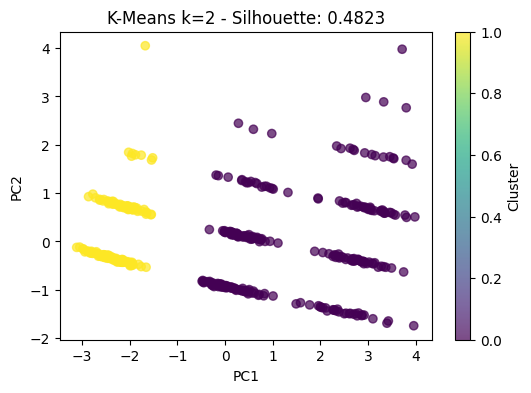

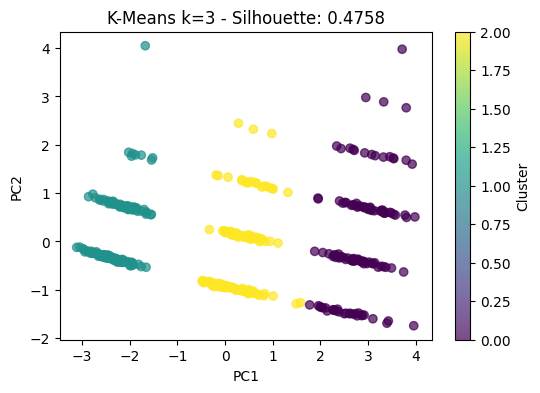

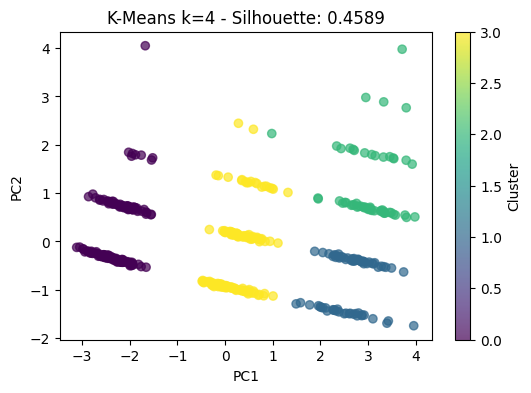

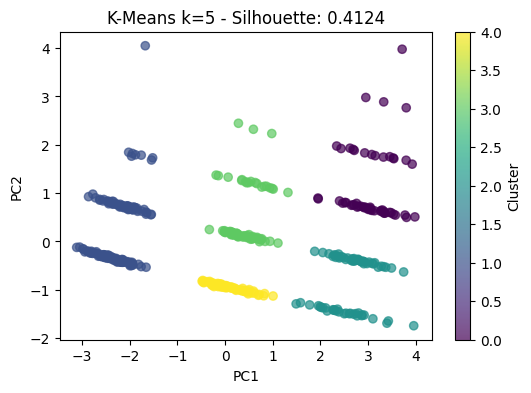


3. PERFILADO DEL MEJOR K

Usando k=2...

Perfil de clusters:
          ingresos  compras_12m  ticket_medio  visitas_web  \
cluster                                                      
0       54,003.760       15.030       135.300       62.250   
1       24,220.900        3.020        40.340       12.550   

         dias_desde_ultima_compra  reclamaciones  
cluster                                           
0                          16.700          1.010  
1                          80.390          0.460  

4. NOMBRES DE NEGOCIO POR CLUSTER

Cluster 0:
  Caracteristicas principales: ingresos, ticket_medio
  -> Perfil: Clientes de altos ingresos
  -> Comportamiento: Alta frecuencia de compra

Cluster 1:
  Caracteristicas principales: ingresos, dias_desde_ultima_compra
  -> Perfil: Clientes de ingresos moderados/bajos
  -> Comportamiento: Baja frecuencia de compra

5. PROPUESTA DE ACCIONES COMERCIALES

ACCIONES RECOMENDADAS POR SEGMENTO:

1. CLIENTES VIP (altos ingresos + alta frecuen

In [15]:
# EJERCICIO INTEGRADOR - Solución Completa

print("=" * 60)
print("1. COMPARACIÓN: k=2, 3, 4, 5")
print("=" * 60)

k_values = [2, 3, 4, 5]
resultados_k = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    resultados_k.append({'k': k, 'silhouette': score})
    print(f"k={k}: silhouette={score:.4f}")

df_resultados = pd.DataFrame(resultados_k)
print("\n-> Mejor k por silhouette:", df_resultados.sort_values('silhouette', ascending=False).iloc[0]['k'])

print("\n" + "=" * 60)
print("2. VISUALIZACIÓN CON PCA PARA CADA K")
print("=" * 60)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    pca_temp = PCA(n_components=2)
    coords = pca_temp.fit_transform(X_scaled)
    
    plt.figure(figsize=(6, 4))
    plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.title(f'K-Means k={k} - Silhouette: {silhouette_score(X_scaled, labels):.4f}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(label='Cluster')
    plt.show()

print("\n" + "=" * 60)
print("3. PERFILADO DEL MEJOR K")
print("=" * 60)

# Select best k (highest silhouette)
mejor_k = int(df_resultados.sort_values('silhouette', ascending=False).iloc[0]['k'])
print(f"\nUsando k={mejor_k}...")

km_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

perfil = df.groupby('cluster')[features].mean().round(2)
print("\nPerfil de clusters:")
print(perfil)

print("\n" + "=" * 60)
print("4. NOMBRES DE NEGOCIO POR CLUSTER")
print("=" * 60)

for cluster_id in range(mejor_k):
    cluster_data = perfil.loc[cluster_id]
    print(f"\nCluster {cluster_id}:")
    
    # Find top 2 features
    top_features = cluster_data.sort_values(ascending=False).head(2)
    print(f"  Caracteristicas principales: {', '.join(top_features.index)}")
    
    # Business interpretation
    if cluster_data['ingresos'] > df['ingresos'].mean():
        print("  -> Perfil: Clientes de altos ingresos")
    else:
        print("  -> Perfil: Clientes de ingresos moderados/bajos")
        
    if cluster_data['compras_12m'] > df['compras_12m'].mean():
        print("  -> Comportamiento: Alta frecuencia de compra")
    else:
        print("  -> Comportamiento: Baja frecuencia de compra")

print("\n" + "=" * 60)
print("5. PROPUESTA DE ACCIONES COMERCIALES")
print("=" * 60)

print("""
ACCIONES RECOMENDADAS POR SEGMENTO:

1. CLIENTES VIP (altos ingresos + alta frecuencia):
   -> Programa de fidelizacion premium
   -> Acceso anticipado a nuevos productos
   -> Servicio al cliente dedicado

2. CLIENTES EN RIESGO (baja frecuencia + dias desde ultima compra altos):
   -> Campanas de reactivacion agresivas
   -> Descuentos personalizados
   -> Encuestas de satisfaccion

3. CLIENTES REGULARES (perfil medio):
   -> Upselling hacia productos premium
   -> Programas de referidos
   -> Cross-selling estacional

4. CLIENTES NUEVOS (pocas compras + visitas web altas):
   -> Onboarding personalizado
   -> Incentivos a la primera compra
   -> Retargeting digital
""")

print("\n" + "=" * 60)
print("ENTREGABLE: TABLA DE PERFILES Y CONCLUSION")
print("=" * 60)
print("\nTabla de perfiles promedio por cluster:")
print(perfil)
print("\n-> Conclusion: La segmentacion permite personalizar estrategias")
print("  comerciales, optimizando el ROI de marketing y mejorando")
print("  la experiencia del cliente.")
